# Soil grain size from photos — a 5-feature texture model + measuring cobbles with SAM

**Public LB 36.19** (the same model without the cobble step: 57.45). No deep learning is trained.
The only pretrained network is SAM, which is used to *measure* stones, not to predict curves.

## TL;DR

| | What it does | Why |
|---|---|---|
| **A. Texture model** | 5 "how much texture at each scale" numbers per photo → Ridge → a **Weibull curve** (2 parameters) | 24 training samples are too few for a CNN; a few physically scaled features transfer across phones |
| **B. Cobble measurement** | **SAM** cuts the stones out of the *full-resolution* test photos; the area share of stones longer than 63 mm / 20 mm redraws the 63 mm and 20 mm points | The training set has almost no cobbles, so no model trained on it can say "30 % of this sample is > 63 mm". But you can *see* the stones in the photo, so measure them |

Step B changes **one test sample only** (`HPC_Muenster_BS6_9_0-10m`); the other 9 rows are exactly model A.
That single sample moved the Public LB by −21, which tells you how much one coarse sample weighs in a 3-sample Public set
(see the honest caveats at the end before you copy this).

## 1. The problem in one picture

For each soil sample we get 1–5 phone photos and must output a cumulative grading curve: the % of mass finer than
11 sieve sizes (0.002 … 200 mm). The metric is the area between the true and predicted curves on a log-size axis
(log-weighted EMD), so **an error of 1 point at every size costs ≈ 5**, and the coarse end (20, 63 mm) counts as much as the clay end.

Three facts drive every design choice below:

1. **Tiny data**: 24 training samples, 10 test samples.
2. **The phones swap**: training photos come from Motorola / Samsung, test photos only from iPhone 14 / 16.
   Training photos were also **downscaled to ≈ 4.6 px/mm and saved as JPEG quality ≈ 75**, while test photos are
   **full resolution (14–20 px/mm) at quality ≈ 94**. The same soil therefore *looks* different in train and test.
3. **No cobbles in training**: almost every training curve reaches ~100 % at 63 mm. A test sample full of 60–150 mm stones
   is outside anything the model has seen.

## 2. Pipeline

```
                    ┌──────────────── A. texture model (train + test) ────────────────┐
 photo ──► [1] make it look like a training photo (downscale to ~4.6 px/mm, re-JPEG with the training q-tables)
           [2] grayscale, common scale 4.5 px/mm, centre crop 50 %
           [3] 5 band energies from Difference-of-Gaussians (0.25→0.5 … 4→8 mm)
           [4] Ridge → (ln b, c) → Weibull curve per photo → average per sample ──────┐
                                                                                       │
 full-res photo ──► [5] SAM automatic masks at 2 px/mm → keep stone-like masks         │
 (test + H374)          → A63, A20 = image-area share of stones longer than 63 / 20 mm │
                                                                                       ▼
                    [6] if A63 ≥ 2 %:  63 mm point = 100 − k·A63,  20 mm point = 100 − k·A20,
                        points ≤ 20 mm shrunk proportionally;  k calibrated once on H374
                                                                                       ▼
                                                                              submission.csv
```

### Step by step — what and why

| Step | What | Why this and not the obvious alternative |
|---|---|---|
| **[1] Train-like path** | Photos sharper than 6 px/mm are downscaled (INTER_AREA) to the median training scale and re-saved as JPEG with the **quantisation tables copied from a training photo** (4:2:0) | Fine-scale texture (~1 mm) depends on resolution and JPEG blocking. Making the *test* photo go through the same degradation as the training photos is cheaper and safer than trying to "undo" the degradation |
| **[2] Physical scale** | px/mm = table ppm × (actual long side / table width); every photo resized to 4.5 px/mm | Grain size is a length. If one pixel means a different number of mm per phone, any texture feature is meaningless across phones |
| **[3] DoG band energies** | Blur at σ = 0.25, 0.5, 1, 2, 4, 8 mm; feature *k* = log(std(blur<sub>k−1</sub> − blur<sub>k</sub>) / std(image)). 5 numbers per photo. No colour | A "sieve in image space": each band measures how much contrast lives at grains of that size. Dividing by the image std removes exposure/contrast differences. Colour shifts systematically between phones and was dropped |
| **[4] Weibull output** | Curve F(d) = 100·(1 − exp(−(d/b)<sup>c</sup>)). Each training label is converted to (ln b, c) by **minimising the competition EMD**; Ridge predicts (ln b, c); curves are averaged per sample | Two numbers, and the shape is fixed by physics rather than learned from 24 curves. A PCA basis learned from the training curves has no "cobble" direction at all |
| **[5] SAM stones** | `facebook/sam-vit-base` automatic mask generation on the full-res photo at 2 px/mm. Keep masks that are ≥ (8 mm)², ≤ 50 % of the image, not mostly covered by a larger stone, and round enough (fill ≥ 0.35). Long axis = 4σ of the mask's pixel coordinates | Hand-made watershed / contour segmentation either merged stones or split one stone along its surface pattern. SAM separates stones cleanly at 2 px/mm, where surface texture is already blurred away |
| **[6] Redraw 63 / 20 mm** | Area share → mass share with **one** factor k, chosen so that training sample **H374** (the only training sample with full-res photos *and* visible stones) gets its true "% coarser than 20 mm". Only samples with A63 ≥ 2 % are touched | A63 / A20 are areas on the surface, not sieved mass. One global factor is the least we can assume; no search, no per-sample tuning |

### Validation

Sites are grouped (sample IDs with the same letter and numbers within 12 → 13 sites), and each site is held out in turn.
Within that, the model is trained on **one training phone and validated on the other** (both directions), to imitate
the phone swap. Gravel and non-gravel samples are weighted 0.2 / 0.8 to resemble the test composition.
Step B only touches test photos, so **CV is identical with and without it** — it can only be checked on H374 and on the LB.

## 3. Setup

Kaggle settings: **GPU on** (SAM; ~1 min on a GPU, ~25 min on CPU) and **Internet on** (to download `facebook/sam-vit-base`).

In [1]:
import io
import re
import time
import unicodedata
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image, ImageOps
from scipy.optimize import minimize
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

IS_KAGGLE = Path("/kaggle/input").exists()
if IS_KAGGLE:
    INPUT_DIR = sorted(Path("/kaggle/input").glob("**/Training_labels_updated.csv"))[0].parent
    OUTPUT_DIR = Path("/kaggle/working")
else:
    INPUT_DIR = Path("input")
    OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SIZES = [0.002, 0.0063, 0.02, 0.063, 0.2, 0.63, 2, 6.3, 20, 63, 200]
SIZE_COLS = ["0.002", "0.0063", "0.02", "0.063", "0.2", "0.63", "2", "6.3", "20", "63", "200"]
W_EMD = np.diff(np.log10(SIZES))          # widths of the 10 log-size intervals
CAM_EDGE, CAM_A52 = "Motorola Edge", "Samsung A52"

CFG = {
    "target_ppm": 4.5,                    # common scale [px/mm]; below the training photos' ~4.6, so everything is downscaled
    "crop_frac": 0.5,                     # centre crop (avoid tray edges and vignetting)
    "dog_sigmas_mm": [0.25, 0.5, 1.0, 2.0, 4.0, 8.0],
    "train_like_above_ppm": 6.0,          # photos sharper than this go through the train-like path
    "ridge_alpha": 1.0,
    "weights_group": {"gravel": 0.2, "non_gravel": 0.8},
    # Weibull label fit: grid for the starting point, then Nelder-Mead
    "grid_lnb": [-6.0, 4.0, 41], "grid_c": [0.1, 2.0, 39], "c_floor": 0.02,
    # SAM stone measurement (fixed before looking at the LB; not tuned)
    "sam_model": "facebook/sam-vit-base", "sam_min_ppm": 12.0, "work_ppm": 2.0, "work_crop": 0.12,
    "pred_iou_thresh": 0.86, "stability_score_thresh": 0.9, "points_per_batch": 64,
    "overlap_drop": 0.5, "min_fill": 0.35, "min_side_mm": 8.0, "max_area_frac": 0.5,
    "apply_if_A63_ge": 0.02,
}
print("input:", INPUT_DIR)

input: /kaggle/input/competitions/soil-grain-size-from-photos


## 4. Index the photos

File names are messy (`iPhone_16_…`, `iPhone14_…`, `Münster`, `9,0`, `(1)` vs `_01`). Every photo must map to a
sample ID, otherwise a sample would silently be predicted from zero photos — so anything unexpected raises.
The effective px/mm is the table value scaled by the real image width (training photos were downscaled after the table was made).

In [2]:
CAMERA_RE = re.compile(r"^(Motorola_Edge_60_fusion|Motorola_Edge|Samsung_A52|iPhone_?14|iPhone_?16)_(.+?)(?:_\d+| \(\d+\))?$")
CAMERA_KEY = {"Motorola_Edge_60_fusion": "Motorola Edge 60 Fusion", "Motorola_Edge": CAM_EDGE, "Samsung_A52": CAM_A52,
              "iPhone14": "iPhone 14", "iPhone_14": "iPhone 14", "iPhone16": "iPhone 16", "iPhone_16": "iPhone 16"}


def normalize_id(raw: str) -> str:
    """Map the sample part of a file name to the submission ID spelling (ü→ue, ','→'_')."""
    s = unicodedata.normalize("NFC", raw).replace("ü", "ue").replace("ö", "oe").replace("ä", "ae")
    return s.replace(",", "_")


labels = pd.read_csv(INPUT_DIR / "Training_labels_updated.csv", dtype={"sample_id": str}).set_index("sample_id")
sample_sub = pd.read_csv(INPUT_DIR / "sample_submission.csv", dtype={"sample_id": str})
ppm_tab = pd.read_csv(INPUT_DIR / "ppm_updated.csv").set_index("phone")

rows = []
for split, pattern in [("train", "Training-All_Photos*"), ("test", "Test_All_Photos*")]:
    for p in sorted(INPUT_DIR.glob(f"{pattern}/**/*")):
        if p.suffix.lower() not in {".jpg", ".jpeg"}:
            continue
        m = CAMERA_RE.match(unicodedata.normalize("NFC", p.stem))
        if m is None:
            raise ValueError(f"unexpected file name: {p.name}")
        with Image.open(p) as im:
            w, h = im.size
        rows.append({"split": split, "path": p, "camera": CAMERA_KEY[m.group(1)],
                     "sample_id": normalize_id(m.group(2)), "w": w, "h": h})
photos = pd.DataFrame(rows)
photos["ppm_eff"] = [ppm_tab.loc[c, "ppm"] * max(w, h) / ppm_tab.loc[c, "width"]
                     for c, w, h in zip(photos.camera, photos.w, photos.h, strict=True)]
assert sorted(set(photos.query("split == 'train'").sample_id)) == sorted(labels.index)
assert set(photos.query("split == 'test'").sample_id) == set(sample_sub.sample_id)

# soil type from the label (used only for CV weighting): fine / sand / gravel
lab = labels.copy()
lab["type"] = np.select([lab["0.063"] >= 40, (lab["63"] - lab["2"]) >= 40], ["fine", "gravel"], "sand")
lab["group"] = np.where(lab["type"] == "gravel", "gravel", "non_gravel")
print(photos.groupby(["split", "camera"]).agg(photos=("path", "size"), samples=("sample_id", "nunique"),
                                             px_per_mm=("ppm_eff", "median")).round(1))

                               photos  samples  px_per_mm
split camera                                             
test  iPhone 14                    14        3       13.9
      iPhone 16                    21        7       19.5
train Motorola Edge                69       22        4.6
      Motorola Edge 60 Fusion       3        1       12.5
      Samsung A52                  55       22        4.6


## 5. Features: train-like degradation → physical scale → DoG band energies

The test photos are first pushed through the same "downscale + JPEG q≈75" path the training photos went through.
Then every photo is brought to 4.5 px/mm, centre-cropped, and summarised by 5 numbers.

In [3]:
_train_small = photos[(photos.split == "train") & (photos.ppm_eff <= CFG["train_like_above_ppm"])]
TRAIN_LIKE_PPM = float(_train_small.ppm_eff.median())
# copy the JPEG quantisation tables from a real training photo instead of guessing a quality number
TRAIN_QTABLES = Image.open(sorted(_train_small[_train_small.camera == CAM_A52].path)[0]).quantization
print(f"train-like target: {TRAIN_LIKE_PPM:.3f} px/mm")


def to_train_like(rgb: np.ndarray, ppm_eff: float) -> tuple[np.ndarray, float]:
    """Downscale a sharp photo to the training scale and re-save it as JPEG with the training q-tables (4:2:0)."""
    f = TRAIN_LIKE_PPM / ppm_eff
    small = cv2.resize(rgb, (round(rgb.shape[1] * f), round(rgb.shape[0] * f)), interpolation=cv2.INTER_AREA)
    buf = io.BytesIO()
    Image.fromarray(small).save(buf, format="JPEG", qtables=TRAIN_QTABLES, subsampling=2)
    return np.asarray(Image.open(io.BytesIO(buf.getvalue())).convert("RGB")), TRAIN_LIKE_PPM


def load_gray(path: Path, ppm_eff: float) -> np.ndarray:
    """EXIF rotation → (train-like path if sharp) → grayscale → landscape → 4.5 px/mm → centre crop."""
    im = ImageOps.exif_transpose(Image.open(path))
    if ppm_eff > CFG["train_like_above_ppm"]:
        rgb, ppm_eff = to_train_like(np.asarray(im.convert("RGB")), ppm_eff)
        im = Image.fromarray(rgb)
    a = np.asarray(im.convert("L"))
    if a.shape[0] > a.shape[1]:
        a = np.ascontiguousarray(np.rot90(a))          # top-down shots: orientation carries no information
    f = CFG["target_ppm"] / ppm_eff
    a = cv2.resize(a, (round(a.shape[1] * f), round(a.shape[0] * f)), interpolation=cv2.INTER_AREA)
    h, w = a.shape
    ch, cw = int(h * CFG["crop_frac"]), int(w * CFG["crop_frac"])
    return a[(h - ch) // 2:(h - ch) // 2 + ch, (w - cw) // 2:(w - cw) // 2 + cw].astype(np.float32)


def dog_features(g: np.ndarray) -> dict[str, float]:
    """Energy of the difference between neighbouring blur levels, relative to the image contrast (log)."""
    blurs = [cv2.GaussianBlur(g, (0, 0), s * CFG["target_ppm"]) for s in CFG["dog_sigmas_mm"]]
    sd = float(g.std()) + 1e-6
    return {f"dog_{s}mm": float(np.log(np.std(blurs[k - 1] - blurs[k]) / sd + 1e-6))
            for k, s in enumerate(CFG["dog_sigmas_mm"]) if k > 0}


t0 = time.time()
feats = pd.DataFrame([dog_features(load_gray(p, e)) for p, e in zip(photos.path, photos.ppm_eff, strict=True)], index=photos.index)
FEATS = list(feats.columns)
photos = photos.join(feats)
print(f"{len(photos)} photos in {time.time() - t0:.0f} s; features: {FEATS}")

train-like target: 4.597 px/mm
162 photos in 30 s; features: ['dog_0.5mm', 'dog_1.0mm', 'dog_2.0mm', 'dog_4.0mm', 'dog_8.0mm']


## 6. Model: Ridge → Weibull (ln b, c)

Each training curve is first turned into the Weibull pair (ln b, c) that minimises **the competition metric itself**
(a least-squares fit would under-weight the fine end). Ridge then predicts (ln b, c) from the 5 features, one row per photo,
with weight 1/(photos of that sample) so that samples with more photos don't count more. Curves — not parameters —
are averaged per sample, and the result is clipped to [0, 100], made monotone, and the 200 mm point set to 100.

In [4]:
_LOG_SIZES = np.log(np.asarray(SIZES, dtype=float))


def emd(y_true, y_pred) -> np.ndarray:
    """Competition metric per sample: sum over the first 10 points of |error| × log10 interval width."""
    return (np.abs(np.asarray(y_true)[..., :10] - np.asarray(y_pred)[..., :10]) * W_EMD).sum(-1)


def postprocess(curve) -> np.ndarray:
    """Valid submission row: clip to 0–100, running maximum (monotone), 200 mm = 100."""
    c = np.maximum.accumulate(np.clip(np.asarray(curve, dtype=float), 0, 100), axis=-1)
    c[..., -1] = 100.0
    return c


def aggregate(per_img: pd.DataFrame) -> pd.DataFrame:
    """Average the per-photo curves of each sample, then post-process once."""
    agg = per_img.groupby(level=0).mean()
    return pd.DataFrame(postprocess(agg.to_numpy()), index=agg.index, columns=SIZE_COLS)


def weibull_curve(lnb, c) -> np.ndarray:
    """(ln b, c) → % passing at the 11 sizes. c is floored to keep the curve defined."""
    lnb = np.asarray(lnb, dtype=float)[..., None]
    c = np.maximum(np.asarray(c, dtype=float), CFG["c_floor"])[..., None]
    return 100.0 * (1.0 - np.exp(-np.exp(c * (_LOG_SIZES - lnb))))


def fit_weibull_label(y: np.ndarray) -> tuple[float, float]:
    """Fit (ln b, c) to one true curve by minimising the EMD: grid start → Nelder-Mead."""
    g_lnb = np.linspace(CFG["grid_lnb"][0], CFG["grid_lnb"][1], int(CFG["grid_lnb"][2]))
    g_c = np.linspace(CFG["grid_c"][0], CFG["grid_c"][1], int(CFG["grid_c"][2]))
    L, C = np.meshgrid(g_lnb, g_c, indexing="ij")
    e = emd(y, weibull_curve(L.ravel(), C.ravel())).reshape(L.shape)
    k = np.unravel_index(int(np.argmin(e)), e.shape)
    x0 = np.array([L[k], C[k]])
    res = minimize(lambda x: float(emd(y, weibull_curve(x[0], x[1]))), x0, method="Nelder-Mead",
                   options={"xatol": 1e-4, "fatol": 1e-6, "maxiter": 2000})
    x = res.x if res.fun <= e[k] else x0
    return float(x[0]), float(max(x[1], CFG["c_floor"]))


# label-only transform: computed once per training sample (does not use any validation information)
TARGETS = pd.DataFrame({s: fit_weibull_label(lab.loc[s, SIZE_COLS].to_numpy(dtype=float)) for s in lab.index},
                       index=["lnb", "c"]).T


def fit_predict(train_rows: pd.DataFrame, pred_rows: pd.DataFrame, per_image: bool = False) -> pd.DataFrame:
    """Standardise → Ridge → (ln b, c) per photo → Weibull curve → (optionally) average per sample."""
    scaler = StandardScaler().fit(train_rows[FEATS])
    w = 1.0 / train_rows.groupby("sample_id").sample_id.transform("size")
    model = Ridge(alpha=CFG["ridge_alpha"]).fit(scaler.transform(train_rows[FEATS]),
                                                TARGETS.loc[train_rows.sample_id].to_numpy(), sample_weight=w.to_numpy())
    par = model.predict(scaler.transform(pred_rows[FEATS]))
    per_img = pd.DataFrame(weibull_curve(par[:, 0], par[:, 1]), columns=SIZE_COLS, index=pred_rows.sample_id.to_numpy())
    return per_img if per_image else aggregate(per_img)


repr_floor = np.mean([emd(lab.loc[s, SIZE_COLS].to_numpy(), weibull_curve(*TARGETS.loc[s])) for s in lab.index])
print(f"best possible EMD with a Weibull curve (mean over training labels): {repr_floor:.2f}")
print(TARGETS.assign(type=lab["type"]).sort_values("lnb").round(3).T.to_string())

best possible EMD with a Weibull curve (mean over training labels): 7.65
       F827   H405   H668   H549   H126   H493   H666   G190   H617   H030   H616   H037    H516    H181    H038    H183    H637    H371    H366    H372    H615    H367    H368    H374
lnb  -3.563  -3.14  -3.08 -2.965 -2.716 -2.519 -2.383 -2.097 -1.908 -1.747  -1.45  0.729   0.882   1.583    1.69   1.763   1.783   2.071    2.09     2.1   2.103    2.12   2.241   2.419
c      1.02  0.584  0.909  0.895  0.779  1.267  1.211  0.719  0.996  0.718  2.715  0.372   1.053   0.807   0.391    0.88    0.42   0.593   0.582   0.627   0.921   0.642   0.866   0.556
type   fine   fine   fine   fine   fine   fine   fine   fine   sand   sand   sand   sand  gravel  gravel  gravel  gravel  gravel  gravel  gravel  gravel  gravel  gravel  gravel  gravel


## 7. Cross-validation (site hold-out × phone swap)

Expected values for this notebook: **site × cross-phone 50.67**, site leave-one-out 47.53 (lower is better).

In [5]:
ids_sorted = sorted(lab.index, key=lambda s: (s[0], int(s[1:])))
SITE, _g, _prev = {}, 0, None
for _s in ids_sorted:                      # same letter and number gap ≤ 12 → same site
    if _prev is None or _s[0] != _prev[0] or int(_s[1:]) - int(_prev[1:]) > 12:
        _g += 1
    SITE[_s] = f"S{_g:02d}"
    _prev = _s
SITE = pd.Series(SITE)


def weighted(per: dict) -> float:
    """0.2 × gravel mean + 0.8 × non-gravel mean."""
    per = pd.Series(per)
    grp = lab.loc[per.index, "group"]
    return float(sum(CFG["weights_group"][k] * per[grp == k].mean() for k in ["gravel", "non_gravel"]))


tr = photos[photos.split == "train"]
xcam, loso = {}, {}
for st in sorted(SITE.unique()):
    hold = list(SITE.index[SITE.eq(st)])
    p = fit_predict(tr[~tr.sample_id.isin(hold)], tr[tr.sample_id.isin(hold)])
    for s in p.index:
        loso[s] = float(emd(lab.loc[s, SIZE_COLS].to_numpy(), p.loc[s].to_numpy()))
    for src, dst in [(CAM_EDGE, CAM_A52), (CAM_A52, CAM_EDGE)]:      # train on one phone, validate on the other
        v_rows = tr[tr.sample_id.isin(hold) & (tr.camera == dst)]
        if len(v_rows) == 0:
            continue
        p = fit_predict(tr[~tr.sample_id.isin(hold) & (tr.camera == src)], v_rows)
        for s in p.index:
            xcam.setdefault(s, []).append(float(emd(lab.loc[s, SIZE_COLS].to_numpy(), p.loc[s].to_numpy())))
xcam = {s: float(np.mean(v)) for s, v in xcam.items() if len(v) == 2}   # samples seen from both directions

print(f"CV site × cross-phone (weighted): {weighted(xcam):.2f}  ({len(xcam)} samples)")
print(f"CV site leave-one-out (weighted): {weighted(loso):.2f}  ({len(loso)} samples)")
print(pd.Series(loso).groupby(lab["type"]).mean().round(1).rename("LOSO EMD by soil type").to_string())

CV site × cross-phone (weighted): 50.67  (21 samples)
CV site leave-one-out (weighted): 47.53  (24 samples)
type
fine      58.2
gravel    31.3
sand      38.3


## 8. Fit on all training photos and predict the test set (model A)

In [6]:
te = photos[photos.split == "test"]
pred_img = fit_predict(tr, te, per_image=True)
pred_A = aggregate(pred_img)
print(pred_A.round(1).to_string())

                          0.002  0.0063  0.02  0.063   0.2  0.63     2    6.3     20     63    200
HPC_Airbus BS10-4bis7       1.8     3.9   8.8   18.9  38.0  66.0  90.7   99.2  100.0  100.0  100.0
HPC_Airbus BS12-5bis8       1.7     3.6   7.5   15.2  29.5  52.2  79.1   96.1   99.8  100.0  100.0
HPC_Airbus BS6-3            1.2     2.9   7.1   16.7  36.7  67.9  94.2   99.9  100.0  100.0  100.0
HPC_Audorfring              1.2     2.6   5.4   11.0  22.1  41.5  68.3   90.6   98.9  100.0  100.0
HPC_Kleinkummerfeld 18-3    1.2     2.9   6.8   15.6  33.7  62.3  89.4   99.3  100.0  100.0  100.0
HPC_Kleinkummerfeld 2-2     1.3     3.5   9.4   24.0  53.0  85.8  99.1  100.0  100.0  100.0  100.0
HPC_Kleinkummerfeld 2-3     1.9     4.4  10.5   24.1  50.0  80.8  96.1   99.6  100.0  100.0  100.0
HPC_Kleinkummerfeld 9-4     1.2     2.6   5.8   12.5  26.0  49.0  77.6   95.9   99.8  100.0  100.0
HPC_Muenster_BS6_9_0-10m    0.5     1.1   2.2    4.7   9.8  19.7  37.5   62.7   86.6   98.1  100.0
HPC_Testfe

## 9. Measuring stones with SAM (step B)

Model A predicts `HPC_Muenster_BS6_9_0-10m` as ~98 % passing 63 mm — "almost no cobbles" — yet its photos are covered
with 60–150 mm stones. No amount of feature engineering on 24 cobble-free training samples fixes that, so we measure.

* Only full-resolution photos (≥ 12 px/mm) are measured: the 35 test photos and the 3 photos of training sample **H374**
  (the calibration sample). All other training photos are already downscaled and cannot be measured this way.
* Each photo is shrunk to **2 px/mm** (stone outlines survive, the surface pattern that makes segmenters split stones disappears)
  and 12 % is cut from each border (tray edges).
* SAM's automatic mask generator proposes masks. Masks are visited from large to small and kept as a "stone" if they are
  at least (8 mm)², at most 50 % of the image, not more than half covered by an already accepted stone, and fill ≥ 35 % of
  the circle on their long axis (rejects thin gaps and shadows).
* **A63 / A20** = fraction of the image area covered by stones whose long axis is > 63 mm / > 20 mm.

In [7]:
import torch
from transformers import pipeline

DEVICE = 0 if torch.cuda.is_available() else -1
mask_gen = pipeline("mask-generation", model=CFG["sam_model"], device=DEVICE)
print("SAM on", "GPU" if DEVICE == 0 else "CPU (slow: ~30 s per photo)")


def load_work(path: Path, ppm: float) -> np.ndarray:
    """EXIF rotation → 2 px/mm → landscape → cut the borders. RGB uint8."""
    im = ImageOps.exif_transpose(Image.open(path)).convert("RGB")
    w, h = im.size
    f = CFG["work_ppm"] / ppm
    a = cv2.resize(np.asarray(im), (round(w * f), round(h * f)), interpolation=cv2.INTER_AREA)
    if a.shape[0] > a.shape[1]:
        a = np.ascontiguousarray(np.rot90(a))
    H, W = a.shape[:2]
    c = CFG["work_crop"]
    return a[int(H * c):int(H * (1 - c)), int(W * c):int(W * (1 - c))]


def stones_from_masks(masks: list[np.ndarray], tot: int) -> tuple[list[dict], float, np.ndarray]:
    """Keep stone-like, non-overlapping masks. Returns the stones, the covered fraction, and a label image for plotting."""
    order = sorted(range(len(masks)), key=lambda i: -int(masks[i].sum()))
    taken = np.zeros_like(masks[0], dtype=bool)
    label_img = np.zeros(masks[0].shape, dtype=np.int32)
    stones = []
    for i in order:
        m = masks[i]
        sz = int(m.sum())
        if sz < (CFG["min_side_mm"] * CFG["work_ppm"]) ** 2 or sz > CFG["max_area_frac"] * tot:
            continue
        if (m & taken).sum() > CFG["overlap_drop"] * sz:
            continue
        ys, xs = np.nonzero(m)
        pts = np.stack([xs, ys], 1).astype(np.float32)
        pts -= pts.mean(0)
        major = 4.0 * float(np.sqrt(max(np.linalg.eigvalsh(np.cov(pts.T)).max(), 1e-9))) / CFG["work_ppm"]   # 4σ ≈ long axis [mm]
        fill = sz / (np.pi * (major * CFG["work_ppm"] / 2) ** 2 + 1e-9)
        if fill < CFG["min_fill"]:
            continue
        taken |= m
        stones.append({"area_frac": sz / tot, "major_mm": major})
        label_img[m & (label_img == 0)] = len(stones)
    return stones, float(taken.mean()), label_img


targets = photos[photos.ppm_eff >= CFG["sam_min_ppm"]]
print(f"measuring {len(targets)} photos:", targets.groupby(["split", "sample_id"]).size().to_dict())
meas, keep_for_plot = [], {}
t0 = time.time()
for r in targets.itertuples():
    rgb = load_work(r.path, r.ppm_eff)
    out = mask_gen(Image.fromarray(rgb), points_per_batch=CFG["points_per_batch"],
                   pred_iou_thresh=CFG["pred_iou_thresh"], stability_score_thresh=CFG["stability_score_thresh"])
    stones, cover, label_img = stones_from_masks([np.asarray(m) for m in out["masks"]], rgb.shape[0] * rgb.shape[1])
    meas.append({"file": r.path.name, "split": r.split, "sample_id": r.sample_id, "cover": cover, "n_stones": len(stones),
                 "A63": sum(s["area_frac"] for s in stones if s["major_mm"] > 63),
                 "A20": sum(s["area_frac"] for s in stones if s["major_mm"] > 20),
                 "max_stone_mm": max((s["major_mm"] for s in stones), default=0.0)})
    if r.sample_id not in keep_for_plot:
        keep_for_plot[r.sample_id] = (rgb, label_img)
meas = pd.DataFrame(meas)
print(f"done in {time.time() - t0:.0f} s")
ms = meas.groupby("sample_id").agg(photos=("file", "size"), A63=("A63", "mean"), A20=("A20", "mean"),
                                   cover=("cover", "mean"), max_stone_mm=("max_stone_mm", "max"))
print(ms.round(3).sort_values("A20", ascending=False).to_string())

config.json:   0%|          | 0.00/6.57k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  375MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/314 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/466 [00:00<?, ?B/s]

SAM on GPU
measuring 38 photos: {('test', 'HPC_Airbus BS10-4bis7'): 3, ('test', 'HPC_Airbus BS12-5bis8'): 3, ('test', 'HPC_Airbus BS6-3'): 3, ('test', 'HPC_Audorfring'): 5, ('test', 'HPC_Kleinkummerfeld 18-3'): 3, ('test', 'HPC_Kleinkummerfeld 2-2'): 3, ('test', 'HPC_Kleinkummerfeld 2-3'): 3, ('test', 'HPC_Kleinkummerfeld 9-4'): 3, ('test', 'HPC_Muenster_BS6_9_0-10m'): 5, ('test', 'HPC_Testfeld Lidl WHV'): 4, ('train', 'H374'): 3}


[transformers] You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


done in 217 s
                          photos    A63    A20  cover  max_stone_mm
sample_id                                                          
HPC_Muenster_BS6_9_0-10m       5  0.249  0.715  0.822       103.818
HPC_Testfeld Lidl WHV          4  0.009  0.435  0.618        63.455
H374                           3  0.015  0.190  0.311        64.702
HPC_Audorfring                 5  0.000  0.061  0.158        42.069
HPC_Airbus BS10-4bis7          3  0.000  0.004  0.019        29.077
HPC_Kleinkummerfeld 2-3        3  0.000  0.002  0.005        21.540
HPC_Airbus BS12-5bis8          3  0.000  0.000  0.008        17.303
HPC_Kleinkummerfeld 2-2        3  0.000  0.000  0.006        15.118
HPC_Kleinkummerfeld 18-3       3  0.000  0.000  0.001         9.850
HPC_Airbus BS6-3               3  0.000  0.000  0.010        19.309
HPC_Kleinkummerfeld 9-4        3  0.000  0.000  0.003        17.507


What SAM picked up (each colour = one accepted stone). Muenster is almost entirely covered by stones; the iPhone 16
samples have none above ~20 mm; H374 is only partly covered — keep that in mind for the calibration.

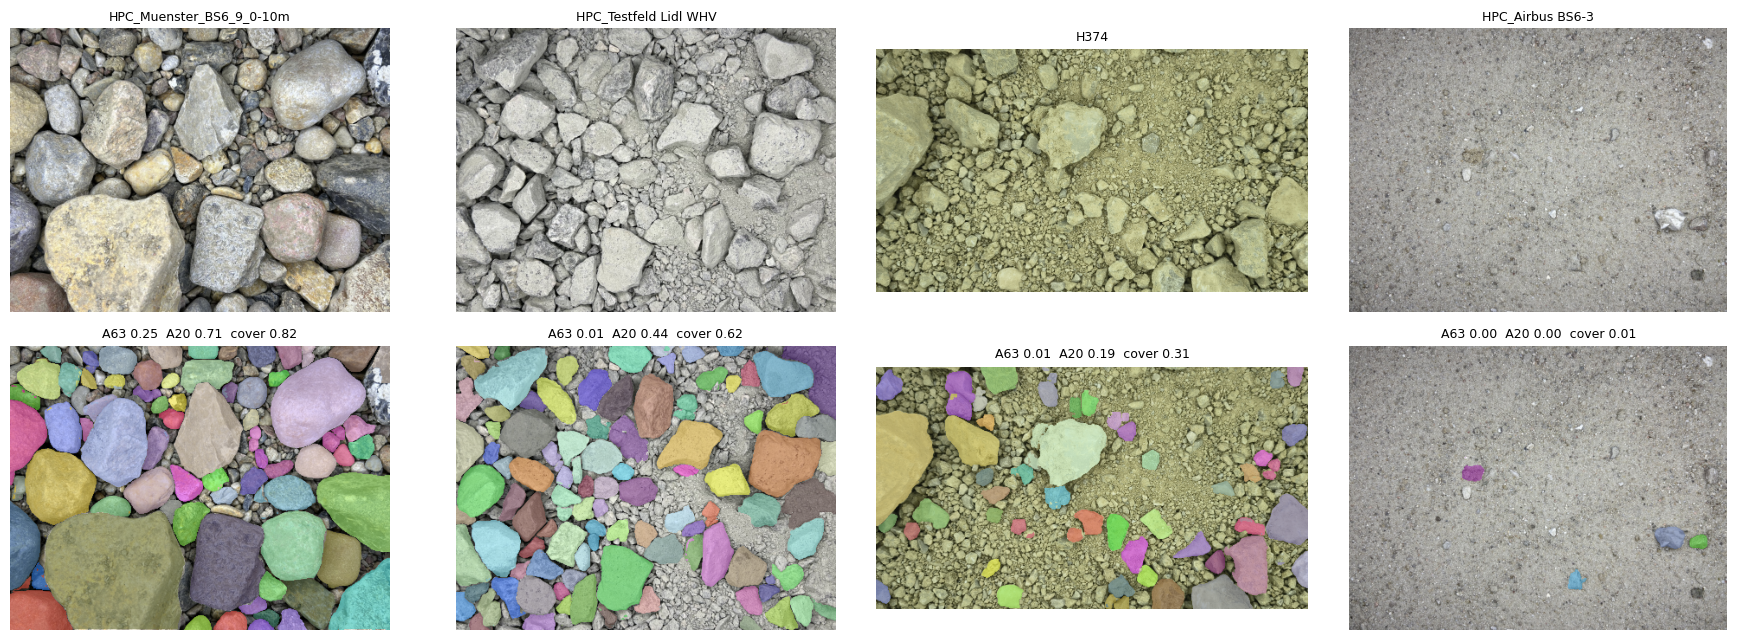

In [8]:
show = ["HPC_Muenster_BS6_9_0-10m", "HPC_Testfeld Lidl WHV", "H374", "HPC_Airbus BS6-3"]
show = [s for s in show if s in keep_for_plot]
fig, axes = plt.subplots(2, len(show), figsize=(4.5 * len(show), 6.5))
rng = np.random.default_rng(0)
for j, sid in enumerate(show):
    rgb, label_img = keep_for_plot[sid]
    colours = rng.integers(40, 255, size=(label_img.max() + 1, 3)).astype(np.uint8)
    colours[0] = 0
    over = np.where(label_img[..., None] > 0, (0.45 * rgb + 0.55 * colours[label_img]).astype(np.uint8), rgb)
    axes[0, j].imshow(rgb)
    axes[0, j].set_title(sid[:28], fontsize=9)
    axes[1, j].imshow(over)
    m = ms.loc[sid]
    axes[1, j].set_title(f"A63 {m.A63:.2f}  A20 {m.A20:.2f}  cover {m.cover:.2f}", fontsize=9)
    for a in axes[:, j]:
        a.axis("off")
plt.tight_layout()
plt.show()

## 10. From stone area to the 63 mm and 20 mm points

Area on the surface is not sieved mass, so we need **one** conversion factor k. The only training sample that both has
full-resolution photos and visible stones is **H374** (true: 23.5 % coarser than 20 mm), so

  k = (100 − F<sub>20,true</sub>(H374)) / (100 · A20(H374))

Then, for each test sample with **A63 ≥ 2 %** (in practice only Muenster):

* 20 mm point → 100 − k·100·A20, 63 mm point → 100 − k·100·A63 (kept ≥ the 20 mm point)
* every point ≤ 20 mm is multiplied by (new 20 mm / old 20 mm) when the curve moves to the coarse side, so the shape of the
  fine part predicted by model A is kept but scaled down
* 200 mm stays 100

Everything else is model A unchanged.

In [9]:
assert "H374" in ms.index, "calibration sample H374 was not measured"
K_CAL = (100.0 - lab.loc["H374", "20"]) / (100.0 * ms.loc["H374", "A20"])
print(f"k = {K_CAL:.3f}   (H374: true > 20 mm {100 - lab.loc['H374', '20']:.1f} %, measured A20 {100 * ms.loc['H374', 'A20']:.1f} %;"
      f" true > 63 mm {100 - lab.loc['H374', '63']:.1f} %, measured A63 {100 * ms.loc['H374', 'A63']:.1f} %)")
I20, I63 = SIZE_COLS.index("20"), SIZE_COLS.index("63")


def redraw(curve: np.ndarray, a63: float, a20: float) -> np.ndarray:
    """Replace the 63 / 20 mm points by the measurement; scale the points ≤ 20 mm when moving to the coarse side."""
    c = np.asarray(curve, dtype=float).copy()
    new20 = max(100.0 - K_CAL * 100.0 * a20, 0.0)
    new63 = max(100.0 - K_CAL * 100.0 * a63, new20)
    scale = new20 / max(c[I20], 1e-6)
    if scale < 1:
        c[: I20 + 1] *= scale
    c[I20], c[I63], c[-1] = new20, new63, 100.0
    return c


final, changed = {}, []
for sid in pred_A.index:
    a63 = float(ms.loc[sid, "A63"]) if sid in ms.index else 0.0
    a20 = float(ms.loc[sid, "A20"]) if sid in ms.index else 0.0
    if a63 >= CFG["apply_if_A63_ge"]:
        final[sid] = redraw(pred_A.loc[sid].to_numpy(), a63, a20)
        changed.append(sid)
    else:
        final[sid] = pred_A.loc[sid].to_numpy()
pred_B = pd.DataFrame(postprocess(np.stack([final[s] for s in pred_A.index])), index=pred_A.index, columns=SIZE_COLS)
print("redrawn samples:", changed)
for sid in changed:
    print(pd.DataFrame({"model A": pred_A.loc[sid], "A + stones": pred_B.loc[sid]}).T.round(1).to_string(), "\n")

k = 1.238   (H374: true > 20 mm 23.5 %, measured A20 19.0 %; true > 63 mm 7.4 %, measured A63 1.5 %)
redrawn samples: ['HPC_Muenster_BS6_9_0-10m']
            0.002  0.0063  0.02  0.063  0.2  0.63     2   6.3    20    63    200
model A       0.5     1.1   2.2    4.7  9.8  19.7  37.5  62.7  86.6  98.1  100.0
A + stones    0.1     0.1   0.3    0.6  1.3   2.6   5.0   8.3  11.5  69.2  100.0 



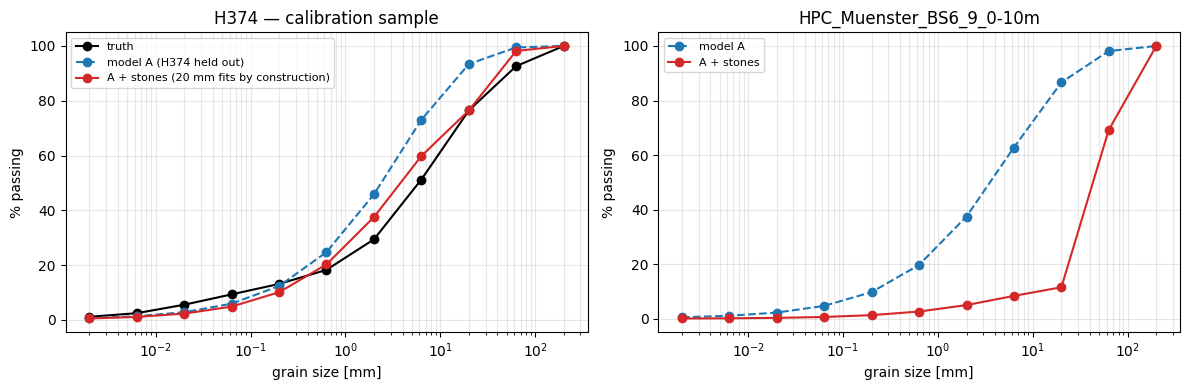

In [10]:
fig, axes = plt.subplots(1, max(len(changed), 1) + 1, figsize=(6 * (max(len(changed), 1) + 1), 4))
h374_A = fit_predict(tr[tr.sample_id != "H374"], tr[tr.sample_id == "H374"]).loc["H374"]     # H374 left out
axes[0].semilogx(SIZES, lab.loc["H374", SIZE_COLS], "k-o", label="truth")
axes[0].semilogx(SIZES, h374_A, "C0--o", label="model A (H374 held out)")
axes[0].semilogx(SIZES, redraw(h374_A.to_numpy(), ms.loc["H374", "A63"], ms.loc["H374", "A20"]), "C3-o",
                 label="A + stones (20 mm fits by construction)")
axes[0].set_title("H374 — calibration sample")
for ax, sid in zip(axes[1:], changed, strict=False):   # no redrawn sample → empty panel
    ax.semilogx(SIZES, pred_A.loc[sid], "C0--o", label="model A")
    ax.semilogx(SIZES, pred_B.loc[sid], "C3-o", label="A + stones")
    ax.set_title(sid)
for ax in axes:
    ax.set_xlabel("grain size [mm]")
    ax.set_ylabel("% passing")
    ax.grid(alpha=0.3, which="both")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 11. Submission

In [11]:
sub = sample_sub[["sample_id"]].merge(pred_B, left_on="sample_id", right_index=True, how="left")
vals = sub[SIZE_COLS].to_numpy()
assert list(sub.columns) == list(sample_sub.columns)
assert not np.isnan(vals).any(), "missing prediction"
assert ((vals >= 0) & (vals <= 100)).all() and (np.diff(vals, axis=1) >= 0).all() and (vals[:, -1] == 100).all()
sub.to_csv(OUTPUT_DIR / "submission.csv", index=False, float_format="%.4f")
sample_sub[["sample_id"]].merge(pred_A, left_on="sample_id", right_index=True).to_csv(
    OUTPUT_DIR / "submission_model_A_only.csv", index=False, float_format="%.4f")
sub.round(1)

,sample_id,0.002,0.0063,0.02,0.063,0.2,0.63,2,6.3,20,63,200
0,HPC_Airbus BS6-3,1.2,2.9,7.1,16.7,36.7,67.9,94.2,99.9,100.0,100.0,100.0
1,HPC_Audorfring,1.2,2.6,5.4,11.0,22.1,41.5,68.3,90.6,98.9,100.0,100.0
2,HPC_Muenster_BS6_9_0-10m,0.1,0.1,0.3,0.6,1.3,2.6,5.0,8.3,11.5,69.2,100.0
3,HPC_Airbus BS10-4bis7,1.8,3.9,8.8,18.9,38.0,66.0,90.7,99.2,100.0,100.0,100.0
4,HPC_Airbus BS12-5bis8,1.7,3.6,7.5,15.2,29.5,52.2,79.1,96.1,99.8,100.0,100.0
5,HPC_Kleinkummerfeld 2-2,1.3,3.5,9.4,24.0,53.0,85.8,99.1,100.0,100.0,100.0,100.0
6,HPC_Kleinkummerfeld 2-3,1.9,4.4,10.5,24.1,50.0,80.8,96.1,99.6,100.0,100.0,100.0
7,HPC_Kleinkummerfeld 9-4,1.2,2.6,5.8,12.5,26.0,49.0,77.6,95.9,99.8,100.0,100.0
8,HPC_Kleinkummerfeld 18-3,1.2,2.9,6.8,15.6,33.7,62.3,89.4,99.3,100.0,100.0,100.0
9,HPC_Testfeld Lidl WHV,0.6,1.2,2.4,4.7,9.0,17.0,31.1,52.2,77.1,94.5,100.0


## 12. Honest caveats — read before copying

* **The LB gain comes from one sample.** Public LB is computed on 3 fixed test samples. Only Muenster changed here, so the
  −21 on Public is Muenster alone. The 7 iPhone 16 test samples show no stone above ~20 mm and are **not touched at all**;
  whatever the Private set (7 samples, 70 % of the final score) contains, step B can only reach it through the 3 iPhone 14
  samples, and of those only Muenster changed.
* **The calibration is weak.** k comes from a single sample with 3 photos. On H374, SAM covers only ~30 % of the image
  (Muenster: ~80 %) — its photos are darker and the stone/sand boundary is softer — and A63 is measured as ~1.5 % against a
  true 7.4 %. The fact that the 20 mm point of H374 fits is by construction, not a validation.
* **Area ≠ mass, surface ≠ volume.** Large stones lying on top hide fines underneath; the single factor k absorbs this only
  on average.
* **Measurement vs texture disagree on gravel ranking.** In my runs, among the measured photos, the stone share A20 and the 8 mm texture
  band rank the photos differently in ~26 % of cases, so the measurement is not yet a reliable ruler beyond the
  "obviously full of cobbles" case.
* SAM on GPU vs CPU can give slightly different masks, so A63 / A20 (and the Muenster row) may differ a little between runs.
  Reference values from a CPU run: k ≈ 1.24, Muenster A63 ≈ 0.25, A20 ≈ 0.72.

What I'd try next: calibrate on more full-resolution photos with known gradings (external, freely available data), normalise
brightness before SAM, or replace the factor k with the stereological identity "area fraction = volume fraction"
(Delesse's principle).